### Applying different data preparation methods and ML models on "income_evaluation" dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Datasets/income_evaluation.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.nunique()

age                   73
 workclass             9
 fnlwgt            21648
 education            16
 education-num        16
 marital-status        7
 occupation           15
 relationship          6
 race                  5
 sex                   2
 capital-gain        119
 capital-loss         92
 hours-per-week       94
 native-country       42
 income                2
dtype: int64

In [4]:
df.isnull().any().any()

False

In [5]:
df.columns = df.columns.str.strip()
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [6]:
df.drop(["fnlwgt"], axis=1, inplace=True)
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

### Data Preprocessing

#### Dealing with education column

In [62]:
df["education"].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [63]:
df["education"] = df["education"].str.strip()
df["education"] = df["education"].map({'Bachelors':1, 'Masters':2,'Doctorate':3})
df.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,1.0,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,1.0,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,NaN,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [7]:
df["education"] = df["education"].fillna(0)
df.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


#### Turning the income, sex into binary form


In [9]:
df["income"] = pd.get_dummies(df["income"], drop_first=True)  # 0 is <=50k, 1 is >50k
df.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0


In [10]:
df["sex"] = pd.get_dummies(df["sex"], drop_first=True)  # 1 is Male, 0 is Female
df.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,13,United-States,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,1,0,0,40,United-States,0


C:\Users\99450\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='capital-gain'>

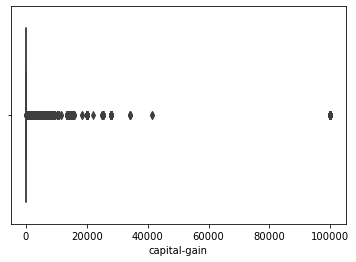

In [11]:
sns.boxplot(df["capital-gain"])

In [68]:
print(len(df))
print(len(df[df["capital-gain"]>0]))
print(len(df[df["capital-gain"]==0]))

32561
2712
29849


C:\Users\99450\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='capital-loss'>

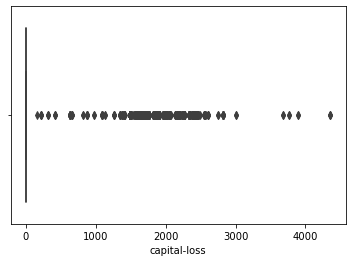

In [69]:
sns.boxplot(df["capital-loss"])

In [70]:
print(len(df[df["capital-loss"]>0]))
print(len(df[df["capital-loss"]==0]))

1519
31042


In [71]:
print(df["capital-gain"].value_counts())
print("---------------------------------------")
print(df["capital-loss"].value_counts())

0        29849
15024      347
7688       284
7298       246
99999      159
         ...  
1111         1
2538         1
22040        1
4931         1
5060         1
Name: capital-gain, Length: 119, dtype: int64
---------------------------------------
0       31042
1902      202
1977      168
1887      159
1848       51
        ...  
2080        1
1539        1
1844        1
2489        1
1411        1
Name: capital-loss, Length: 92, dtype: int64


#### So, I think we don't need to use 'capital-loss' and 'capital-gain' columns

In [12]:
df.drop(["capital-gain", "capital-loss"], axis=1,inplace = True)
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,1,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,1,13,United-States,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,1,40,United-States,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,40,United-States,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,40,Cuba,0


In [13]:
df.corr()

,age,education-num,sex,hours-per-week,income
age,1.000000,0.036527,0.088832,0.068756,0.234037
education-num,0.036527,1.000000,0.012280,0.148123,0.335154
sex,0.088832,0.012280,1.000000,0.229309,0.215980
hours-per-week,0.068756,0.148123,0.229309,1.000000,0.229689
income,0.234037,0.335154,0.215980,0.229689,1.000000


In [14]:
# Education and Education-num is totally same thing, that is why we should drop one column
df.drop("education", axis=1, inplace=True)
df.head(2)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,1,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,1,13,United-States,0


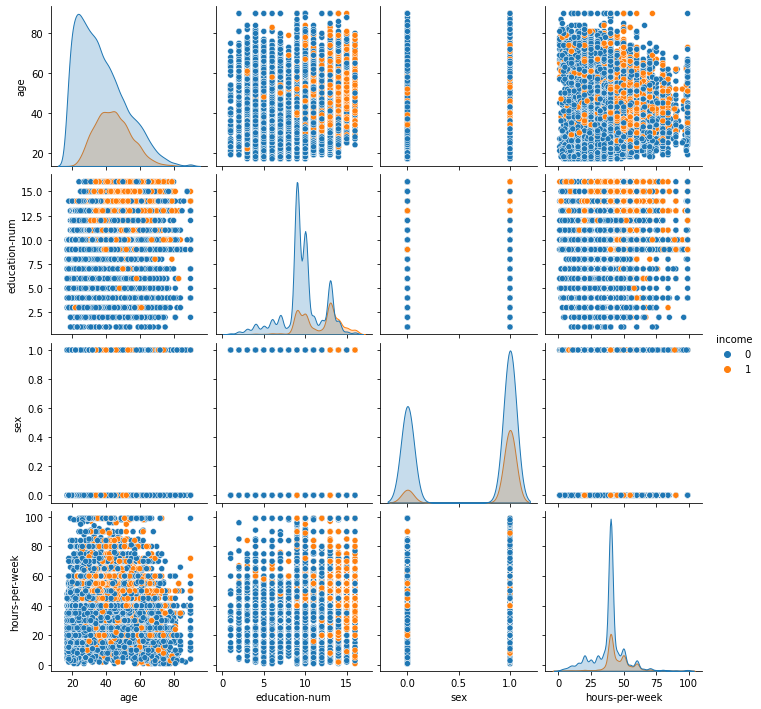

In [75]:
sns.pairplot(df, hue="income")

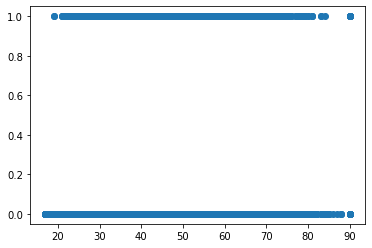

In [16]:
plt.scatter(df["age"],df["income"])
plt.show()

## Modelling 1 - Dropping nominal data and fed into a model (the rest is nominal data) and visualization

In [17]:
df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [18]:
data = df.copy()
data.drop(["workclass","marital-status","occupation","relationship","race","native-country"], axis=1, inplace=True)
data.head()

,age,education-num,sex,hours-per-week,income
0,39,13,1,40,0
1,50,13,1,13,0
2,38,9,1,40,0
3,53,7,1,40,0
4,28,13,0,40,0


In [19]:
data.loc[:,:"income"]

,age,education-num,sex,hours-per-week,income
0,39,13,1,40,0
1,50,13,1,13,0
2,38,9,1,40,0
3,53,7,1,40,0
4,28,13,0,40,0
...,...,...,...,...,...
32556,27,12,0,38,0
32557,40,9,1,40,1
32558,58,9,0,40,0
32559,22,9,1,20,0


In [20]:
data.corr()

,age,education-num,sex,hours-per-week,income
age,1.000000,0.036527,0.088832,0.068756,0.234037
education-num,0.036527,1.000000,0.012280,0.148123,0.335154
sex,0.088832,0.012280,1.000000,0.229309,0.215980
hours-per-week,0.068756,0.148123,0.229309,1.000000,0.229689
income,0.234037,0.335154,0.215980,0.229689,1.000000


## Modelling 1 - Building a Logistic Regression model

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = data.iloc[:,:-1]
y = data.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [22]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

0.8011668969752802

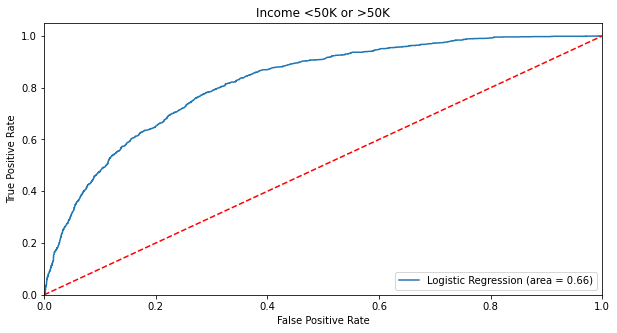

In [23]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, lr.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Income <50K or >50K')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

In [24]:
logit_roc_auc

0.6586151103275398

## Modelling 1 - Building a SVM model

In [25]:
from sklearn.svm import SVC
svm_mod = SVC(kernel="poly", degree=3)
svm_mod.fit(X_train, y_train)
y_pred = svm_mod.predict(X_test)
accuracy_score(y_pred, y_test)

0.8062336864732075

## Modelling 1 - Building a Random Forest model

In [26]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators = 5, 
                             min_samples_split=10, 
                             min_samples_leaf=10,
                            n_jobs = 1)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
accuracy_score(y_pred, y_test)

0.8093044679871028

## Outlier and Distribution Analysis

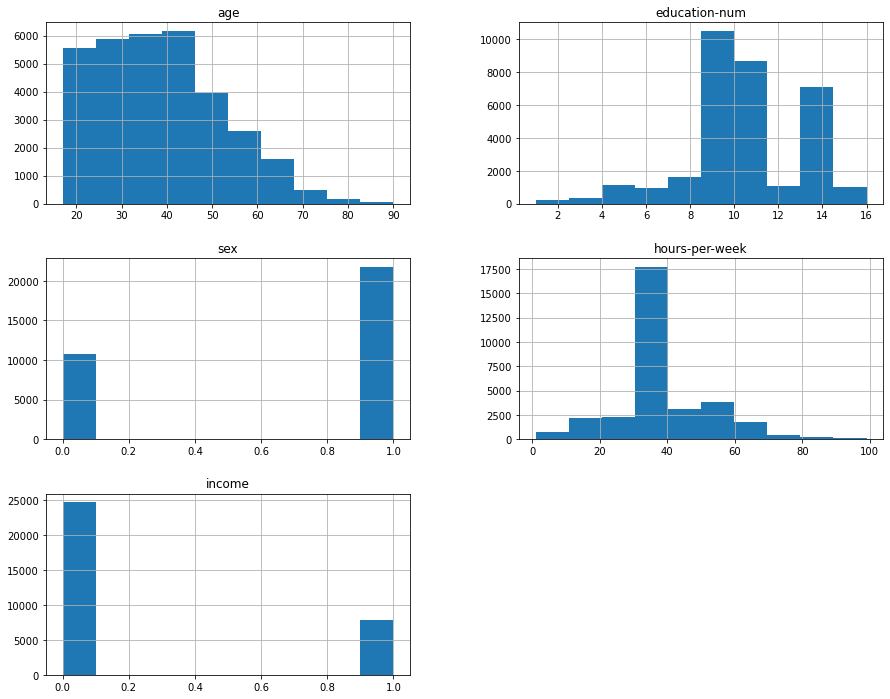

In [27]:
df.hist(figsize=(15,12))
plt.show()

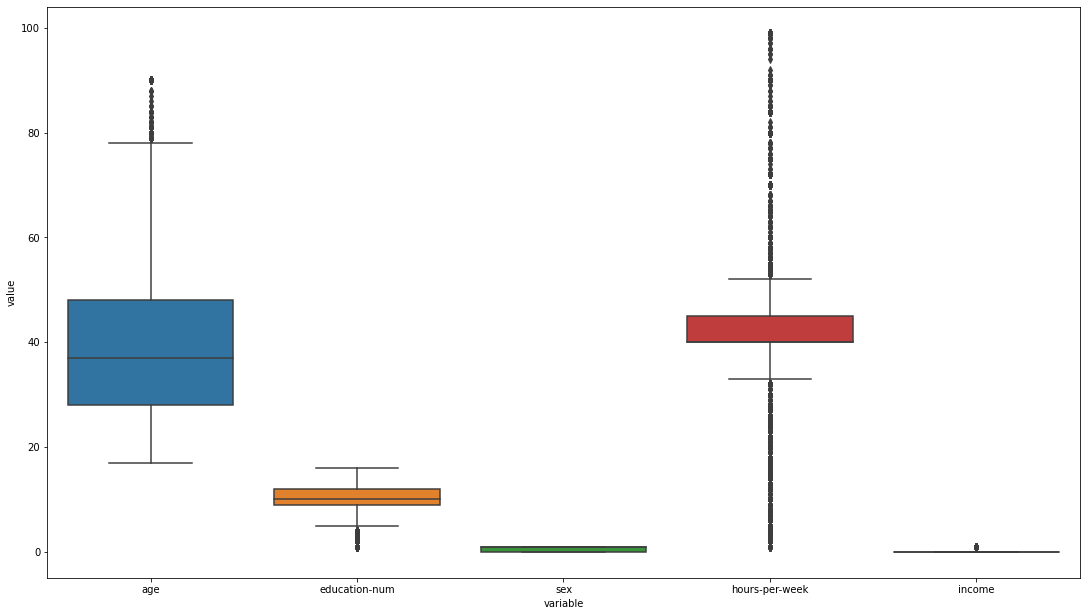

In [28]:
fig = plt.gcf()
fig.set_size_inches(18.5, 10.5)
d_ = pd.DataFrame(data = data, columns = data.columns)
sns.boxplot(x="variable", y="value", data=pd.melt(d_))
plt.show()

In [95]:
df.describe()

,age,education-num,sex,hours-per-week,income
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,0.669205,40.437456,0.240810
std,13.640433,2.572720,0.470506,12.347429,0.427581
min,17.000000,1.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,1.000000,40.000000,0.000000
75%,48.000000,12.000000,1.000000,45.000000,0.000000
max,90.000000,16.000000,1.000000,99.000000,1.000000


In [29]:
# Education num
IQR_ed_num = df.describe()["education-num"]["75%"] - df.describe()["education-num"]["25%"]
ed_num_minimum = df.describe()["education-num"]["25%"] - 1.5*IQR_ed_num
ed_num_minimum

4.5

In [30]:
len(df[df["education-num"] < 4.5])

1198

In [31]:
1198/len(df)

0.036792481803384416

In [32]:
# Age
IQR_age = df.describe()["age"]["75%"] - df.describe()["age"]["25%"]
age_max = df.describe()["age"]["75%"] + 1.5*IQR_age
age_max

78.0

In [100]:
len(df[df["age"] > 78])

143

In [101]:
78/len(df)

0.0023955038235926414

In [102]:
# Hours per week
len(df[(df["hours-per-week"] < 25) | (df["hours-per-week"] > 55)])

6001

In [103]:
### Removing age and education-num
len(df[(df["education-num"] < 4.5) | (df["age"] > 78)])

1320

In [34]:
out_data = df[(df["education-num"] > 4.5) & (df["age"] < 78)]
out_data.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,1,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,1,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,1,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,40,Cuba,0


In [35]:
df.corr()

,age,education-num,sex,hours-per-week,income
age,1.000000,0.036527,0.088832,0.068756,0.234037
education-num,0.036527,1.000000,0.012280,0.148123,0.335154
sex,0.088832,0.012280,1.000000,0.229309,0.215980
hours-per-week,0.068756,0.148123,0.229309,1.000000,0.229689
income,0.234037,0.335154,0.215980,0.229689,1.000000


In [36]:
out_data.corr()

,age,education-num,sex,hours-per-week,income
age,1.000000,0.112672,0.093797,0.102710,0.260628
education-num,0.112672,1.000000,0.032976,0.163409,0.342643
sex,0.093797,0.032976,1.000000,0.233767,0.222191
hours-per-week,0.102710,0.163409,0.233767,1.000000,0.231924
income,0.260628,0.342643,0.222191,0.231924,1.000000


## Modelling 2 - Removing nominal data

In [38]:
out = out_data.copy()
out.drop(["workclass","marital-status","occupation","relationship","race","native-country"], axis=1, inplace=True)
out.head()

,age,education-num,sex,hours-per-week,income
0,39,13,1,40,0
1,50,13,1,13,0
2,38,9,1,40,0
3,53,7,1,40,0
4,28,13,0,40,0


In [39]:
X = out.iloc[:,:-1]
y = out.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## Modelling 2 - Applying Random Forest model

In [40]:
rfc = RandomForestClassifier(n_estimators = 5, 
                             min_samples_split=10, 
                             min_samples_leaf=10,
                            n_jobs = 1)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
accuracy_score(y_pred, y_test)

0.8049639711769415

## Modelling 2 - Applying Logistic Regression model

In [41]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

0.8048038430744595

## Modelling 3 - Encoding nominal data and again applying model on the original dataset (without removing outlayers)

In [42]:
df.head(3)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,1,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,1,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,1,40,United-States,0


In [43]:
df.nunique()

age               73
workclass          9
education-num     16
marital-status     7
occupation        15
relationship       6
race               5
sex                2
hours-per-week    94
native-country    42
income             2
dtype: int64

In [44]:
d = df.copy()
nominal_data = ["workclass","marital-status","occupation","relationship","race","native-country"]
d = pd.get_dummies(d, columns = nominal_data, drop_first = True)

## Modelling 3 - Logistic Regression

In [45]:
X = d.drop("income", axis=1)
y = d.iloc[:,5]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [47]:
X.head()

,age,education-num,sex,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,13,1,40,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,13,1,13,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38,9,1,40,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,7,1,40,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,40,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

C:\Users\99450\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.0

## Modelling 4 - Removing outliers and apply model after encoding nominal data

In [50]:
len(df)

32561

In [51]:
len(out_data)

31225

In [52]:
nominal_data = ["workclass","marital-status","occupation","relationship","race","native-country"]
d2 = pd.get_dummies(out_data, columns = nominal_data, drop_first = True)

X = d2.drop("income", axis=1)
y = d2.iloc[:,5]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [53]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_pred, y_test)

C:\Users\99450\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.0

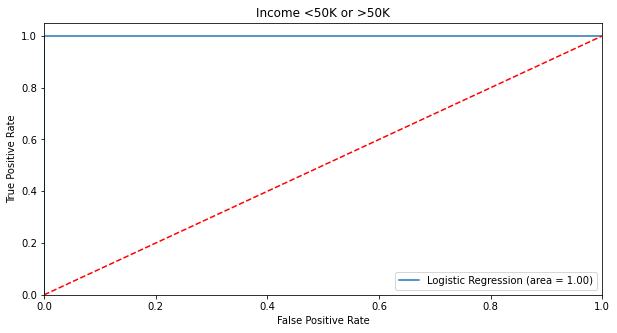

In [54]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, lr.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Income <50K or >50K')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Week 5 - Case Study

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dis = pd.read_csv('../All_datasets/heart.csv')
dis.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [74]:
dis.isnull().any().any()

False

In [75]:
dis.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [76]:
dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<AxesSubplot:>

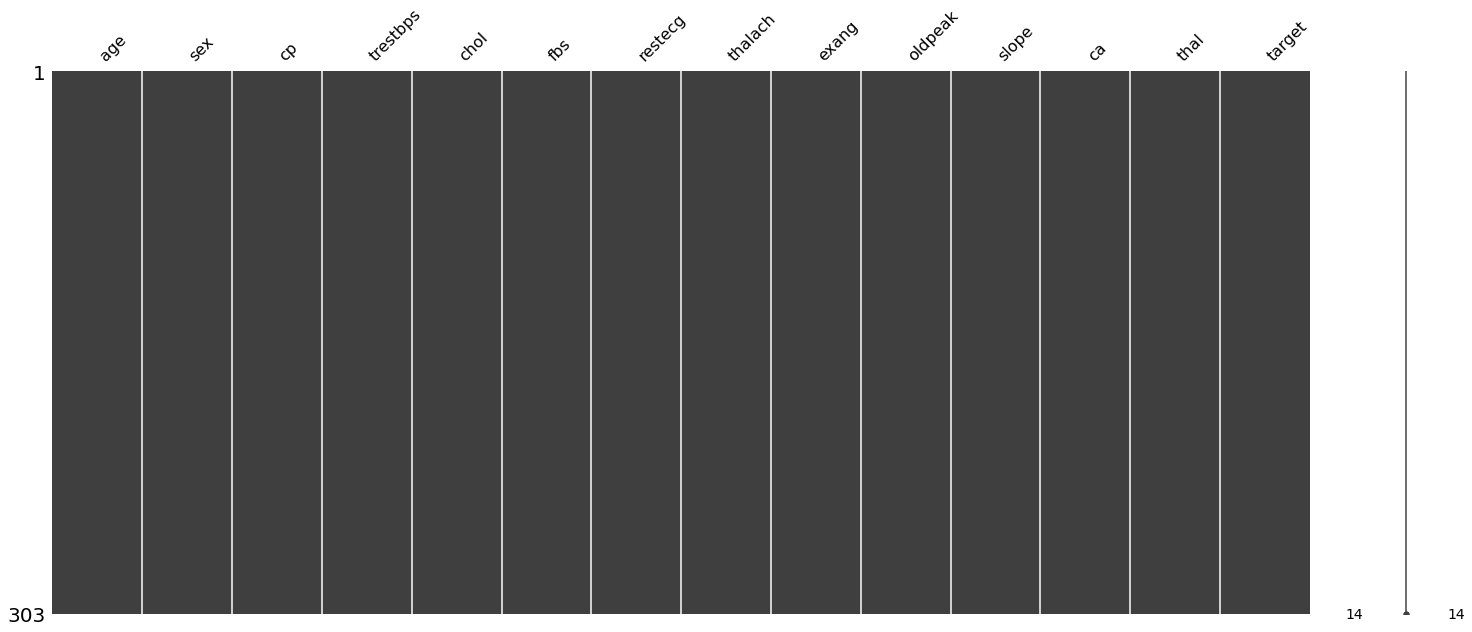

In [77]:
import missingno as msno
msno.matrix(dis)

In [78]:
dis.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = dis.iloc[:,:-1]
y = dis.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [83]:
mod = LogisticRegression()
mod.fit(X_train, y_train)
y_pred = mod.predict(X_test)
accuracy_score(y_pred, y_test)

C:\Users\99450\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8852459016393442

### Dealing with Outliers and Correlation

In [88]:
# I prefer to drop 'fbs' column
# Let's check accuracy by dropping that column
X = dis.iloc[:,:-1].drop("fbs", axis=1)
y = dis.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

mod = LogisticRegression()
mod.fit(X_train, y_train)
y_pred = mod.predict(X_test)
accuracy_score(y_pred, y_test)

C:\Users\99450\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8688524590163934

#### So, accuracy decreases after removing 'fbs' column

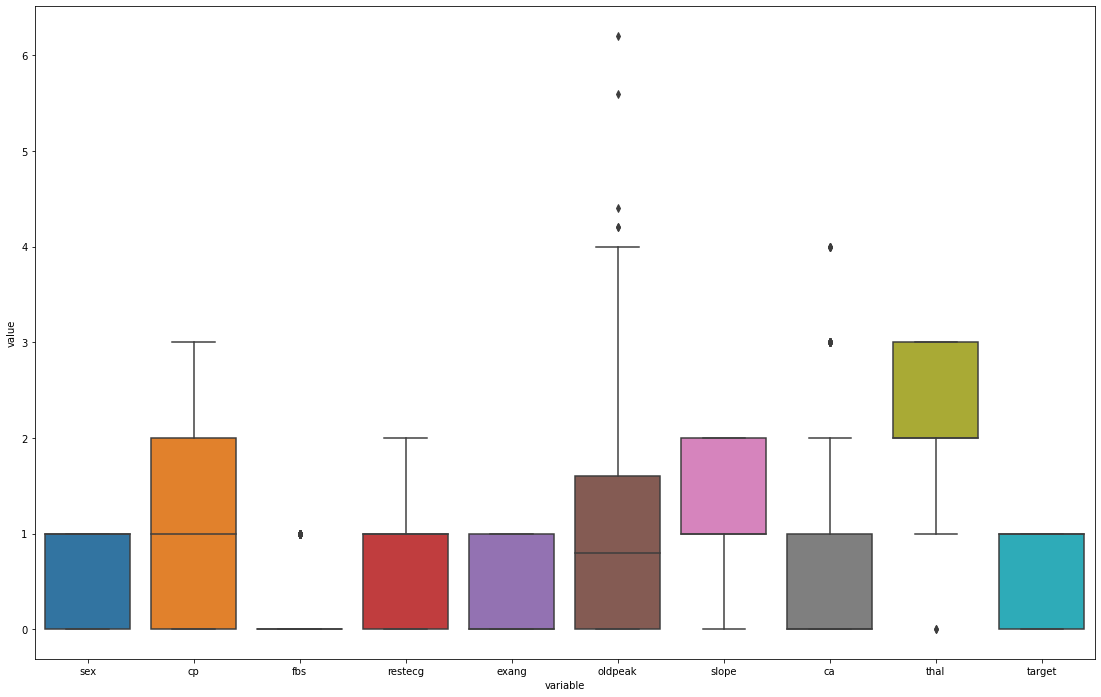

In [87]:
fig = plt.gcf()
fig.set_size_inches(19, 12)
lst = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
d_ = pd.DataFrame(data = dis, columns = lst)
sns.boxplot(x="variable", y="value", data=pd.melt(d_))
plt.show()

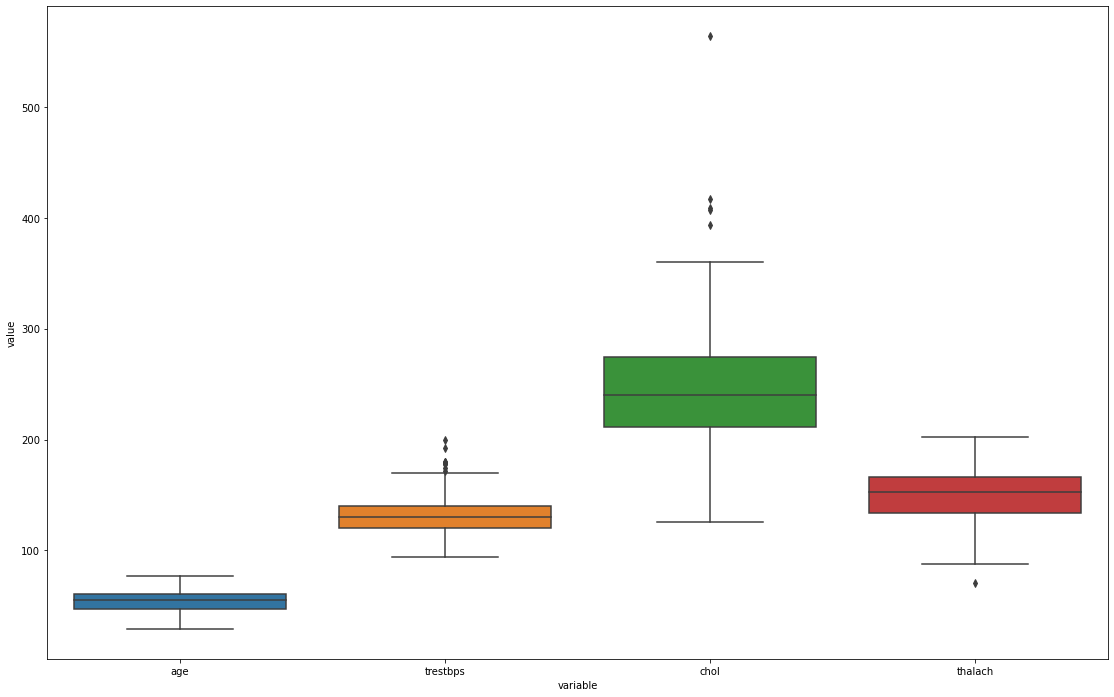

In [90]:
fig = plt.gcf()
fig.set_size_inches(19, 12)
d_ = pd.DataFrame(data = dis, columns = ['age','trestbps', 'chol','thalach'])
sns.boxplot(x="variable", y="value", data=pd.melt(d_))
plt.show()

In [92]:
dis.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [93]:
# trestbps column
trestbps_IQR = dis.describe()["trestbps"]["75%"] - dis.describe()["trestbps"]["25%"]
trestbps_IQR = dis.describe()["trestbps"]["75%"] + 1.5*trestbps_IQR
trestbps_IQR

170.0

In [94]:
# chol column
chol_IQR = dis.describe()["chol"]["75%"] - dis.describe()["chol"]["25%"]
chol_IQR = dis.describe()["chol"]["75%"] + 1.5*chol_IQR
chol_IQR

369.75

In [96]:
# oldpeak column
oldpeak_IQR = dis.describe()["oldpeak"]["75%"] - dis.describe()["oldpeak"]["25%"]
oldpeak_IQR = dis.describe()["oldpeak"]["75%"] + 1.5*oldpeak_IQR
oldpeak_IQR

4.0

In [104]:
x = len(dis)
y = len(dis[(dis["trestbps"] > 170) | (dis["oldpeak"] > 4) | (dis["chol"] > 369.75)])
print("x: ",x)
print("y: ",y)
print("Percentage: ", y/x)

x:  303
y:  18
Percentage:  0.0594059405940594


In [105]:
out_dis = dis[(dis["trestbps"] < 170) & (dis["oldpeak"] < 4) & (dis["chol"] < 369.75)]
len(out_dis)

280

In [106]:
dis.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


In [107]:
out_dis.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.070009,-0.075217,0.261272,0.180989,0.108883,-0.098618,-0.423648,0.088825,0.205805,-0.153240,0.290506,0.047312,-0.227618
sex,-0.070009,1.000000,-0.103220,0.001859,-0.134509,0.083282,-0.075983,-0.048650,0.186928,0.161156,-0.057715,0.164326,0.223861,-0.323779
cp,-0.075217,-0.103220,1.000000,0.075774,-0.091163,0.098123,0.086621,0.291713,-0.374365,-0.098974,0.107203,-0.141742,-0.201018,0.422715
trestbps,0.261272,0.001859,0.075774,1.000000,0.100803,0.124105,-0.104492,-0.063361,-0.017515,0.115158,-0.042061,0.122636,-0.028165,-0.090473
chol,0.180989,-0.134509,-0.091163,0.100803,1.000000,0.021012,-0.146063,-0.023466,0.082240,-0.003028,0.056525,0.077199,0.088177,-0.105130
fbs,0.108883,0.083282,0.098123,0.124105,0.021012,1.000000,-0.078296,-0.018392,-0.002627,0.006923,-0.069319,0.139777,-0.039084,-0.020951
restecg,-0.098618,-0.075983,0.086621,-0.104492,-0.146063,-0.078296,1.000000,0.079486,-0.099424,-0.072380,0.101302,-0.080277,0.041708,0.159505
thalach,-0.423648,-0.048650,0.291713,-0.063361,-0.023466,-0.018392,0.079486,1.000000,-0.372009,-0.339969,0.383383,-0.222949,-0.109125,0.430557
exang,0.088825,0.186928,-0.374365,-0.017515,0.082240,-0.002627,-0.099424,-0.372009,1.000000,0.293315,-0.258569,0.114052,0.215676,-0.421664
oldpeak,0.205805,0.161156,-0.098974,0.115158,-0.003028,0.006923,-0.072380,-0.339969,0.293315,1.000000,-0.539653,0.152084,0.196590,-0.426703


In [108]:
# Let's checl accuracy by removing some of the outliers
X = out_dis.iloc[:,:-1]
y = out_dis.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

mod = LogisticRegression()
mod.fit(X_train, y_train)
y_pred = mod.predict(X_test)
accuracy_score(y_pred, y_test)

C:\Users\99450\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.875

### Distribution and Dependencies of the original data

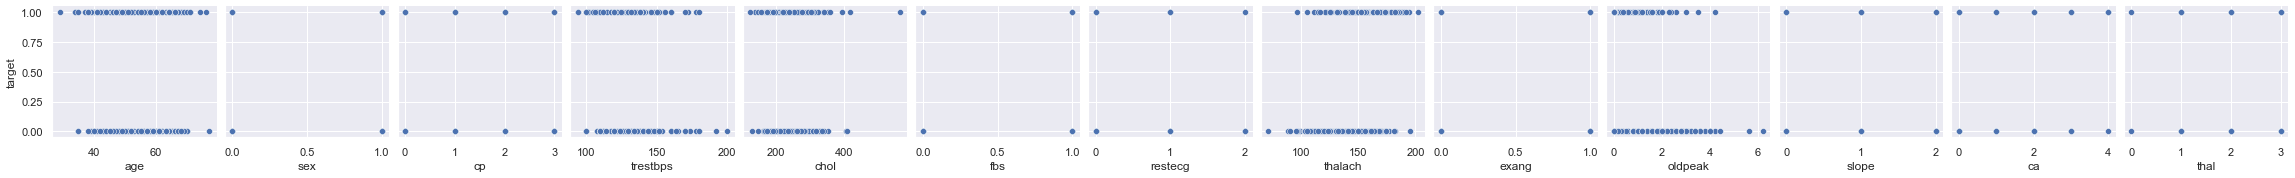

In [119]:
sns.set(rc={'figure.figsize':(15,9)})
sns.pairplot(dis, x_vars=dis.iloc[:,:-1].columns, y_vars = ["target"])

# Modelling

In [124]:
X = dis.iloc[:,:-1]
y = dis.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### Logistic Regression

In [125]:
mod = LogisticRegression()
mod.fit(X_train, y_train)
y_pred = mod.predict(X_test)
accuracy_score(y_pred, y_test)

C:\Users\99450\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8852459016393442

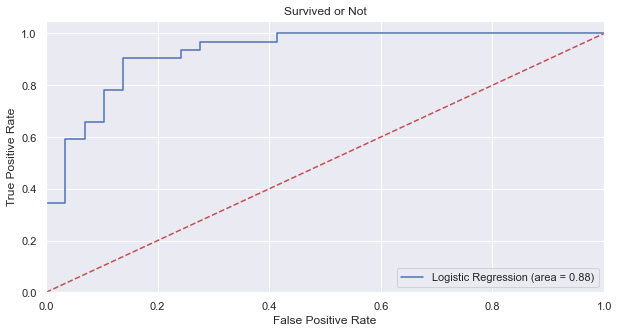

In [126]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, mod.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, mod.predict_proba(X_test)[:,1])
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Survived or Not')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

### Support Vector Machine - RBF kernel

In [134]:
from sklearn.svm import SVC
svc1 = SVC(kernel='rbf')
svc1.fit(X_train, y_train)
y_pred = svc1.predict(X_test)
accuracy_score(y_pred, y_test)

0.7049180327868853

In [135]:
roc_auc_score(y_pred, y_test)

0.7280701754385964

### Support Vector Machine - Linear kernel

In [136]:
svc2 = SVC(kernel='linear')
svc2.fit(X_train, y_train)
y_pred = svc2.predict(X_test)
accuracy_score(y_pred, y_test)

0.8688524590163934

In [137]:
roc_auc_score(y_pred, y_test)

0.8685344827586206

### Gaussian Naive Bayes

In [127]:
from sklearn.naive_bayes import GaussianNB
NBmodel = GaussianNB()
NBmodel.fit(X_train, y_train)
y_pred = NBmodel.predict(X_test)
accuracy_score(y_pred, y_test)

0.8688524590163934

In [129]:
roc_auc_score(y_pred, y_test)

0.8693548387096774

### Decision Tree Classifier

In [144]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(min_samples_split = 5,
                            min_samples_leaf=5,
                            max_leaf_nodes=10)
dtc.fit(X_train,y_train)
y_pred = dtc.predict(X_test)
accuracy_score(y_pred, y_test)

0.8852459016393442

### Random Forest Classifier

In [146]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=10,
                            min_samples_split = 5,
                            min_samples_leaf=5)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
accuracy_score(y_pred, y_test)

0.8688524590163934

### KNN Classifier

In [174]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 11)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy_score(y_pred, y_test)

0.7540983606557377